<a href="https://colab.research.google.com/github/ZakharovGitHub/MMIMVPVS2026/blob/main/%D0%9C%D0%9C%D0%B8%D0%9C%D0%B2%D0%9F%D0%92%D0%A1_%D0%98%D0%BD%D0%B4%D0%97%D0%B0%D0%B4%D0%B0%D0%BD%D0%B8%D0%B5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Индивидуальное задание по дисциплине "Математические методы и модели в параллельных вычислительных системах"

Выполнил студент гр. БСВ23-01 Захаров А. С.

## Импорты

In [12]:
import numpy as np
from IPython.display import display, Math, Markdown
from math import factorial, comb
from itertools import product

## Исходные данные

* Число типов процессоров, $N$ =  2;
* Число процессоров $1$-го типа $m_1$ = 2;
* Число процессоров $2$-го типа $m_2$ = 3;
* Среднее время выполненния команды процессором $1$-го типа $T_{o1}$ = 1.6;
* Среднее время выполненния команды процессором $2$-го типа $T_{o2}$ = 11;
* Время обслуживания запроса процессора $1$-го типа $\tau_1$ = 1.2;
* Время обслуживания запроса процессора $2$-го типа $\tau_2$ = 1.2;
* Параметр связности по памяти $q$ = 0.35;
* Число шин $n$ = 4.

## Оценка производительности МСОИУ

In [2]:
N = 2
m1 = 2
m2 = 3
To1 = 1.6
To2 = 11
tau1 = 1.2
tau2 = 1.2
q = 0.35
n = 4

v1 = (q/n)/(To1-(q/n)*tau1)
v2 = (q/n)/(To2-(q/n)*tau2)
mu1 = 1/tau1
mu2 = 1/tau2

### Интенсивности запросов и обслуживаний процессоров. Проверка условий выполнения стационарного режима

In [3]:
display("Полученные интенсивности запросов и обслуживаний процессоров:")
display(Markdown(rf"* $\nu_1 = {v1}$"))
display(Markdown(rf"* $\nu_2 = {v2}$"))
display(Markdown(rf"* $\mu_1 = {mu1}$"))
display(Markdown(rf"* $\mu_2 = {mu2}$"))

'Полученные интенсивности запросов и обслуживаний процессоров:'

* $\nu_1 = 0.058528428093645474$

* $\nu_2 = 0.008031206975676915$

* $\mu_1 = 0.8333333333333334$

* $\mu_2 = 0.8333333333333334$

In [4]:
display('Проверка условия стационарного режима:')
ro1 = v1/mu1
ro2 = v2/mu2
display(Markdown(rf"* $\rho_1 = {ro1} \le 1$"))
display(Markdown(rf"* $\rho_2 = {ro2} \le 1$"))
display('Стационарный режим выполняется')

'Проверка условия стационарного режима:'

* $\rho_1 = 0.07023411371237456 \le 1$

* $\rho_2 = 0.009637448370812297 \le 1$

'Стационарный режим выполняется'

### Решение СЛАУ

Построенный граф состояний

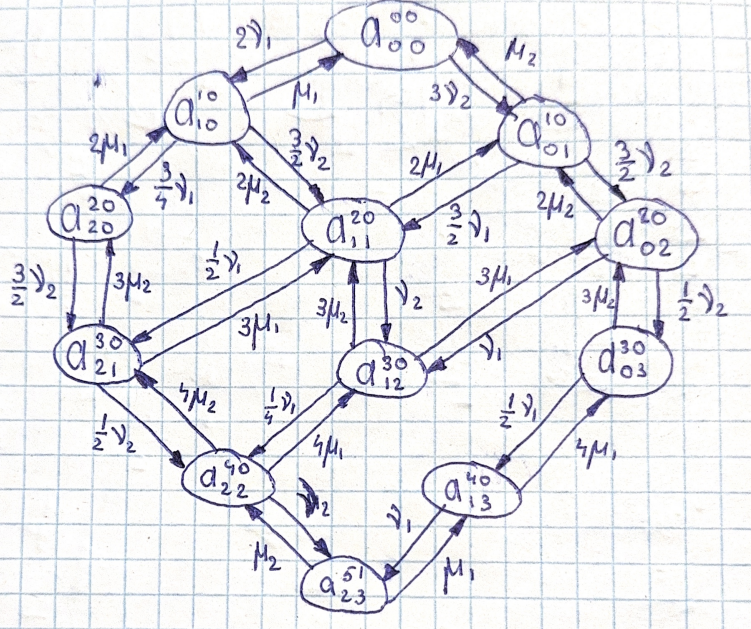

Скомпонованная на основе графа матрица, впоследствии образующая СЛАУ

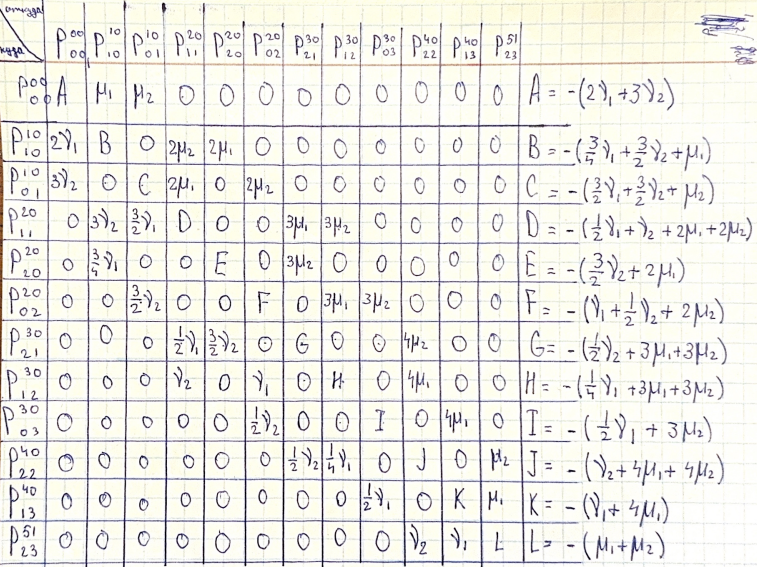

In [5]:
A = [
      [-(2*v1+3*v2),mu1,mu2,0,0,0,0,0,0,0,0,0],
      [2*v1,-(3*v1/4 + 3*v2/2 + mu1),0,2*mu2,2*mu1,0,0,0,0,0,0,0],
      [3*v1,0,-(3*v1/2 + 3*v2/2 + mu2),2*mu1,0,2*mu2,0,0,0,0,0,0],
      [0,3*v2,3*v1/2,-(v1/2 + v2 + 2*mu1 + 2*mu2),0,0,3*mu1,3*mu2,0,0,0,0],
      [0,3*v1/4,0,0,-(3*v2/2 + 2*mu1),0,3*mu2,0,0,0,0,0],
      [0,0,3*v2/2,0,0,-(v1+v2/2+2*mu2),0,3*mu1,3*mu2,0,0,0],
      [0,0,0,v1/2,3*v2/2,0,-(v2/2+3*mu1+3*mu2),0,0,4*mu2,0,0],
      [0,0,0,v2,0,v1,0,-(v1/4+3*mu1+3*mu2),0,4*mu1,0,0],
      [0,0,0,0,0,v2/2,0,0,-(v1/2+3*mu2),0,4*mu1,0],
      [0,0,0,0,0,0,v2/2,v1/4,0,-(v2+4*mu1+4*mu2),0,mu2],
      [0,0,0,0,0,0,0,0,v1/2,0,-(v1+4*mu1),mu1],
      [0,0,0,0,0,0,0,0,0,v2,v1,-(mu1+mu2)],
     ]
A = np.array(A)
np.set_printoptions(linewidth=160)
print(A)

[[-1.41150477e-01  8.33333333e-01  8.33333333e-01  0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
   0.00000000e+00  0.00000000e+00  0.00000000e+00]
 [ 1.17056856e-01 -8.89276465e-01  0.00000000e+00  1.66666667e+00  1.66666667e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
   0.00000000e+00  0.00000000e+00  0.00000000e+00]
 [ 1.75585284e-01  0.00000000e+00 -9.33172786e-01  1.66666667e+00  0.00000000e+00  1.66666667e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
   0.00000000e+00  0.00000000e+00  0.00000000e+00]
 [ 0.00000000e+00  2.40936209e-02  8.77926421e-02 -3.37062875e+00  0.00000000e+00  0.00000000e+00  2.50000000e+00  2.50000000e+00  0.00000000e+00
   0.00000000e+00  0.00000000e+00  0.00000000e+00]
 [ 0.00000000e+00  4.38963211e-02  0.00000000e+00  0.00000000e+00 -1.67871348e+00  0.00000000e+00  2.50000000e+00  0.00000000e+00  0.00000000e+00
   0.00000000e+00  0.00000000e+00  0.00000000e+00]
 [ 0.00000000e+

Осуществляем замену 3 уравнения на условие нормировки

In [6]:
eq_num = 2
A[eq_num] = [1,1,1,1,1,1,1,1,1,1,1,1]
print(A)

[[-1.41150477e-01  8.33333333e-01  8.33333333e-01  0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
   0.00000000e+00  0.00000000e+00  0.00000000e+00]
 [ 1.17056856e-01 -8.89276465e-01  0.00000000e+00  1.66666667e+00  1.66666667e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
   0.00000000e+00  0.00000000e+00  0.00000000e+00]
 [ 1.00000000e+00  1.00000000e+00  1.00000000e+00  1.00000000e+00  1.00000000e+00  1.00000000e+00  1.00000000e+00  1.00000000e+00  1.00000000e+00
   1.00000000e+00  1.00000000e+00  1.00000000e+00]
 [ 0.00000000e+00  2.40936209e-02  8.77926421e-02 -3.37062875e+00  0.00000000e+00  0.00000000e+00  2.50000000e+00  2.50000000e+00  0.00000000e+00
   0.00000000e+00  0.00000000e+00  0.00000000e+00]
 [ 0.00000000e+00  4.38963211e-02  0.00000000e+00  0.00000000e+00 -1.67871348e+00  0.00000000e+00  2.50000000e+00  0.00000000e+00  0.00000000e+00
   0.00000000e+00  0.00000000e+00  0.00000000e+00]
 [ 0.00000000e+

In [7]:
B = np.array([0,0,0,0,0,0,0,0,0,0,0,0])
B[eq_num] = 1
print('B = ', B)

B =  [0 0 1 0 0 0 0 0 0 0 0 0]


Решение уравнения с помощью инструмента из библиотеки *numpy*

In [8]:
P = np.linalg.solve(A,B)
P_names = ['$P_{00}^{00}$', '$P_{10}^{10}$',
  '$P_{01}^{10}$', '$P_{11}^{20}$', '$P_{20}^{20}$',
  '$P_{02}^{20}$', '$P_{21}^{30}$', '$P_{12}^{30}$',
  '$P_{03}^{30}$','$P_{22}^{40}$','$P_{13}^{40}$','$P_{23}^{51}$']
for i in range(12):
  display(Markdown(rf"{P_names[i]} = %.15f"%P[i]))

$P_{00}^{00}$ = 0.850997214930452

$P_{10}^{10}$ = 0.120770166117855

$P_{01}^{10}$ = 0.023372229374615

$P_{11}^{20}$ = 0.001487428062779

$P_{20}^{20}$ = 0.003182376606900

...

$P_{12}^{30}$ = 0.000004373966199

$P_{03}^{30}$ = 0.000000272331149

$P_{22}^{40}$ = 0.000000019460959

$P_{13}^{40}$ = 0.000000002393300

$P_{23}^{51}$ = 0.000000000177823

Прямое вычисление вероятностей состояний МСОИУ при помощи формулы имени проф. Терскова В. А.

In [32]:
N = 2
m = np.array([2, 3])
n = 4
q = 0.35
To = np.array([1.6, 11])
tau = np.array([1.2, 1.2])
v = (q / n) / (To - (q / n) * tau)
mu = 1 / tau
rho = v / mu
M = np.sum(m)
def falling_factorial(x, k):
    if k > x:
        return 0
    return np.prod([x - i for i in range(k)])
def weight(k, l, js):
    js = np.asarray(js)
    kl = k + l
    ff = falling_factorial(n, kl)
    if ff == 0:
        return 0.0
    c1 = comb(kl - 1, l, exact=True)
    c2 = comb(n, k, exact=True)
    num_fact = factorial(kl, exact=True)
    denom_ji = np.prod([factorial(j, exact=True) for j in js])
    if np.any(js > m):
        return 0.0
    prod_m = np.prod([
        factorial(m[i], exact=True) / factorial(m[i] - js[i], exact=True) * (rho[i] ** js[i])
        for i in range(N)
    ])
    return c1 * c2 * (num_fact / denom_ji) * prod_m / ff
allowed_states = [
    (0, 0, (0, 0)),
    (1, 0, (1, 0)),
    (1, 0, (0, 1)),
    (2, 0, (2, 0)),
    (2, 0, (1, 1)),
    (2, 0, (0, 2)),
    (3, 0, (2, 1)),
    (3, 0, (1, 2)),
    (3, 0, (0, 3)),
    (4, 0, (2, 2)),
    (4, 0, (1, 3)),
    (5, 1, (2, 3)),
]
weights = []
for k, l, js in allowed_states[1:]:
    w = weight(k, l, js)
    weights.append(w)
results = {}
results[(0, 0, (0, 0))] = P0
print(f"P_00^00 = {P0:.10f}")

for (k, l, js), w in zip(allowed_states[1:], weights):
    p = w
    name = f"P_{js[0]}{js[1]}^{k}{l}"
    print(f"{name} = {p:.10f}")
    results[(k, l, js)] = p

P_00^00 = 0.8482933645
P_10^10 = 0.1404682274
P_01^10 = 0.0289123451
P_20^20 = 0.0049328307
P_11^20 = 0.0040612659
P_02^20 = 0.0002786412
P_21^30 = 0.0001426197
P_12^30 = 0.0000391402
P_03^30 = 0.0000008951
P_22^40 = 0.0000013745
P_13^40 = 0.0000001257
P_23^51 = 0.0000000000


### Оценка производительности

Совокупные вероятности:

$P_{00} = P_{00}^{00}$

$P_{10} = P_{10}^{10} + P_{01}^{10}$

$P_{20} = P_{20}^{20} + P_{02}^{20} + P_{11}^{20}$

$P_{30} = P_{21}^{30} + P_{12}^{30}$

$P_{41} = P_{22}^{40} + P_{13}^{40}$

$P_{51} = P_{23}^{51}$

In [9]:
P00 = P[0]
P10 = P[1]+P[2]
P20 = P[3]+P[4]+P[5]
P30 = P[6]+P[7]+P[8]
P40 = P[10] + P[9]
P51 = P[11]
l = 0*P00 + 0*P10 + 0*P20 + 0*P30 + 0*P40 + 1*P51
display('Средняя длина очереди: ')
display(Markdown(r"$l_{ср}$ = %.15f"%l))
display('Относительная потеря производительности: ')
theta1 = 1 + (l*tau1)/(To1+tau1)
theta2 = 1 + (l*tau2)/(To2+tau2)
display(Markdown(r"$\theta_1$ = %.15f"%theta1))
display(Markdown(r"$\theta_2$ = %.15f"%theta2))
display('Производительность')
Performance = m1/theta1 + m2/theta2
display(Markdown(r"$П_{ср}$ = %.15f"%Performance))

'Средняя длина очереди: '

$l_{ср}$ = 0.000000000177823

'Относительная потеря производительности: '

$\theta_1$ = 1.000000000076210

$\theta_2$ = 1.000000000017491

'Производительность'

$П_{ср}$ = 4.999999999795109

Где:
*   $l_{ср} = \sum{l \cdot P_{l,k}}$

*   $ \theta_i = 1 + \frac{l_{ср}\tau_i}{T_{oi}+\tau_i}$

*   $ П_{ср} = \sum{\frac{m_i}{\theta_i}}$


